In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as units
import astropy.constants as const
from scipy.special import wofz
from tqdm import tqdm
from rtfunctions import one_full_fs, sc_2nd_order, calc_lambda_full, calc_lambda_monoc
import time
import illuminated_finite_slab as ill

In [2]:
import SLab_linev2 as v2 # Latest version

In [3]:
def iterate_coupled_lines_bc1(self, lines, max_iter=40, tol=1e-4, verbose=False, omega=1.0):
        """
        Iterate lines and slab consistently so lines "see" each other through the slab intensity.

        Algorithm (per outer iteration):
        - Ensure a common global x-grid and per-line normalized profiles exist.
        - Build current composite S_nu(depth) from line.S_line (fallback to B).
        - For all mu and frequency points solve formal RT once per (mu,nu) using composite S_nu to get I(depth,mu,nu).
        - For each line j accumulate J_j(depth) = 0.5 * sum_mu sum_n w_mu w_x phi_j(nu) * I(depth,mu,nu).
        - Update each line.S_line using ALI (diagonal lambda operator) if available, otherwise simple LI:
            S_new = [epsilon B + (1-epsilon) * J_nonlocal] / [1 - (1-epsilon) * Lambda_star]
          where J_nonlocal = J - Lambda_star * S_old.
        - Recompute composite S_nu and repeat until convergence.

        Returns dict with final composite S_nu grid, emergent intensity, per-line S_line, and rel history.
        """
        # prepare global grid & per-line normalized profiles
        self.global_x_grid(lines)
        self.compute_phi(lines, correct_normalization=False)
        # ensure x_weights present
        if getattr(self, "x_weights", None) is None or self.x_weights.size != self.x_values.size:
            dx = self.x_values[1] - self.x_values[0]
            self.x_weights = np.ones_like(self.x_values) * dx

        # ensure mu grid exists
        if getattr(self, "mu_values", None) is None or getattr(self, "mu_weights", None) is None:
            self.mu_grid(self.NM if self.NM is not None else 8, verbose=False, diffuse=True)

        Nfreq = len(self.x_values)
        ND = len(self.tau)
        Nmu = len(self.mu_values)

        # Ensure each line has phi_x_global and initialize S_line if missing
        for line in lines:
            if not hasattr(line, "phi_x_global"):
                line.compute_phi_x(self.x_values)
                norm = np.sum(line.phi_x * self.x_weights)
                line.phi_x_global = line.phi_x / norm if norm != 0.0 else line.phi_x.copy()
            if getattr(line, "S_line", None) is None:
                line.S_line = np.copy(self.B)

        # Using simple Lambda iteration only: no precomputed Lambda_star or ALI acceleration.

        rel_history = []
        for outer in tqdm(range(max_iter)):
            # build current composite S_nu on global grid (depth x freq)
            S_nu = self.composite_S(lines)  # uses current line.S_line internally

            # allocate J arrays per line (depth)
            J_lines = [np.zeros(ND) for _ in lines]

            # Loop over angles and frequencies once, using composite S_nu for formal solution
            for m in range(Nmu):
                mu = self.mu_values[m]
                w_mu = self.mu_weights[m]
                for l in range(Nfreq):
                    w_x = self.x_weights[l]
                    # total opacity at this freq: sum over lines (k*phi + r)
                    tau_lambda = np.zeros_like(self.tau)
                    for line in lines:
                        phi_l = line.phi_x_global[l]
                        tau_lambda += self.tau * (line.k * phi_l + self.r)
                    # formal solution for this (mu,nu) with frequency-dependent S_nu[:,l]
                    # include both outward and inward rays so lines see the correct illumination
                    # outward ray (from bottom, bottom boundary assumed zero)
                    I_out = sc_2nd_order(tau_lambda, S_nu[:, l], mu, 0.0)
                    I_out_depth = I_out[0]
                    # inward ray (from top) uses actual top illumination
                    top_bc = self.get_boundary_radiation(mu)
                    I_in = sc_2nd_order(tau_lambda, S_nu[:, l], -mu, 0.0)
                    I_in_depth = I_in[0]

                    # sum contributions from both directions
                    I_depth_sum = I_out_depth + I_in_depth

                    # accumulate J for each line using its phi at this frequency (use 1/2 when summing ±μ)
                    for j, line in enumerate(lines):
                        phi_j = line.phi_x_global[l]
                        J_lines[j] += 0.5 * w_mu * w_x * phi_j * I_depth_sum
            # Now update each line's S_line using ALI / diagonal ALO if possible
            max_rel = 0.0
            tiny = 1e-20  # small threshold to avoid division by zero
            for j, line in enumerate(lines):
                J = J_lines[j]
                S_old = line.S_line

                # Simple LI update instead of ALI
                S_new = line.epsilon * line.B + (1.0 - line.epsilon) * J

                # under-relaxation
                S_updated = S_old + omega * (S_new - S_old)
                # measure relative change
                rel = np.max(np.abs((S_updated - S_old) / np.where(np.abs(S_updated) > tiny, S_updated, tiny)))
                max_rel = max(max_rel, rel)

                # store update
                line.S_line = S_updated

            rel_history.append(max_rel)
            if verbose:
                print(f"iterate_coupled_lines iter {outer:3d} max_rel={max_rel:.3e}")

            # update composite S and emergent intensity for diagnostics / next iteration
            S_nu = self.composite_S(lines)
            I_emergent = self.formal_solution(lines, mu=1.0, boundary_condition=1.0)

            # check convergence
            if max_rel < tol:
                if verbose:
                    print(f"iterate_coupled_lines converged after {outer} iterations (rel={max_rel:.3e})")
                break
        else:
            if verbose:
                print("iterate_coupled_lines: did not converge within max_iter")

        # final outputs
        final_S_nu = self.composite_S(lines)
        final_I = self.formal_solution(lines, mu=1.0, boundary_condition=1.0)
        return {
            "S_nu": final_S_nu,
            "I_emergent": final_I,
            "S_lines": [line.S_line.copy() for line in lines],
            "rel_history": np.array(rel_history)
        }

<h1>26. 02. 2026.</h1>
<p>Implementing various tests with regard to number of line components in the slab model. Later, we shall study how the optical thinckness/thiness of the lines affects the composite source function.</p>

<h2>1) One line</h2>

In [4]:
# Create a slab
# Define the input parameters
ND = 81
tau_max = 1e3
epsilon = np.ones(ND) * 1e-3
B = np.ones(ND) * 1.0
H = 80000.0 # Height of the slab above the solar surface in kilometers
slab_one_line = v2.Slab(ND, tau_max, epsilon, B, H)

In [5]:
# The line
line_one_1 = v2.Slab.Line(81, line_center=0.0, a=0.1, k=1.0, slab_in=slab_one_line)
#line_one_2 = v2.Slab.Line(81, line_center=0.5, a=0.1, k=0.5, slab_in=slab_one_line)
lines_one = [line_one_1]
slab_one_line.global_x_grid(lines_one)
line_one_1.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line.x_values)
#line_one_2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line.x_values)

  6%|▌         | 56/1000 [00:02<00:37, 24.93it/s]

Convergence achieved after 56 iterations with max dS = 8.42e-07


  1%|          | 22/2000 [00:01<01:46, 18.57it/s]


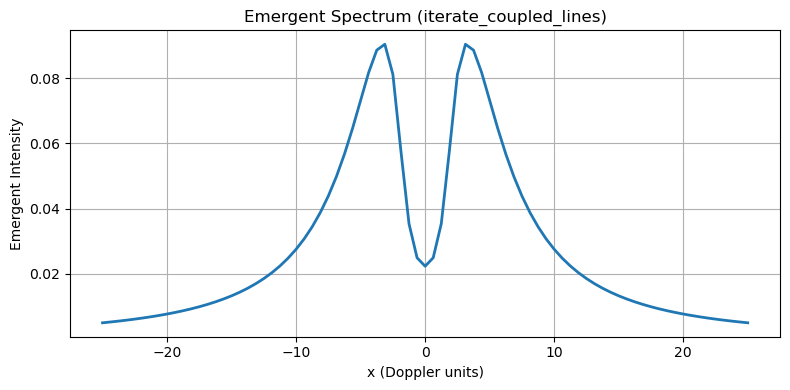

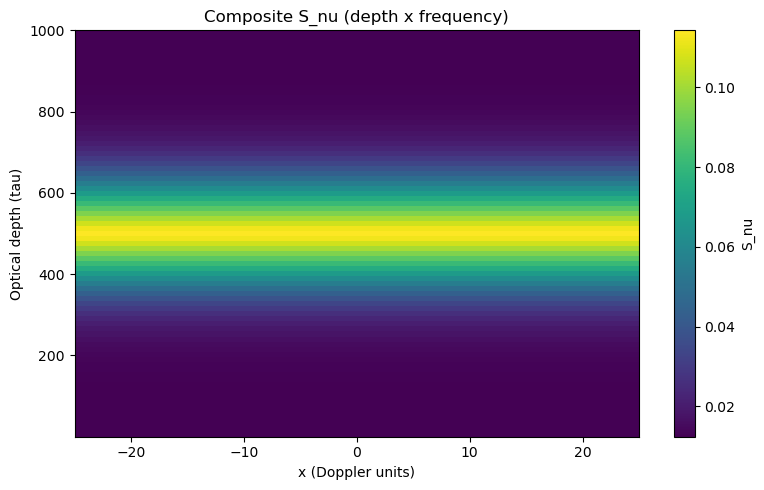

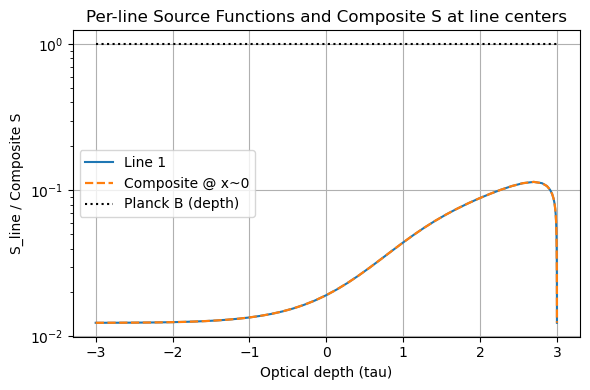

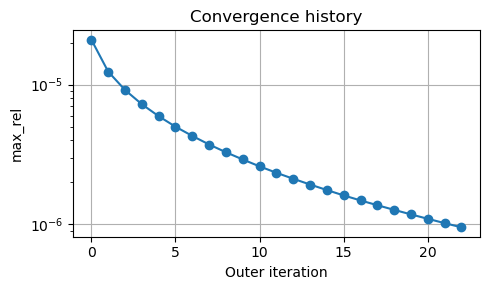

Line 1 phi normalization (sum phi*xw): 1


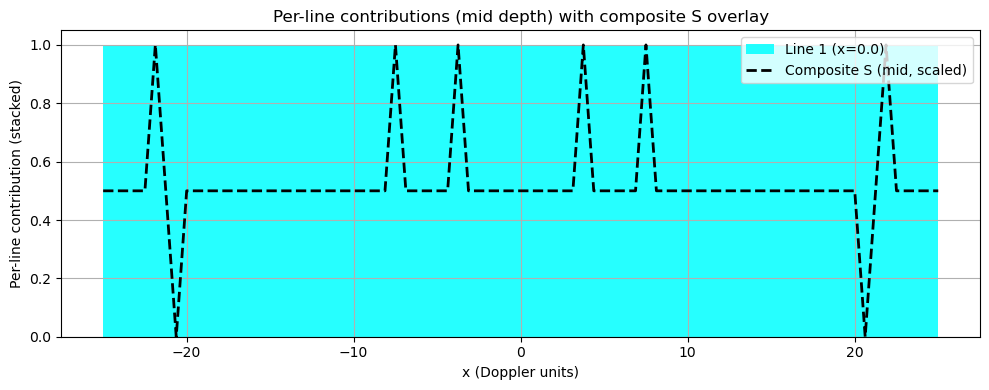

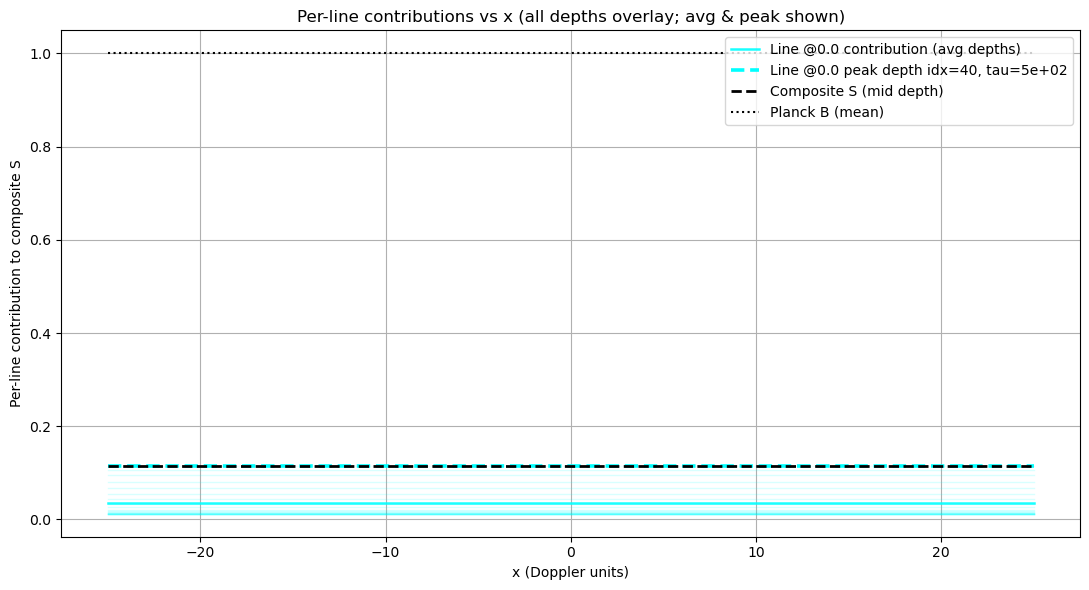

  0%|          | 0/2000 [00:00<?, ?it/s]


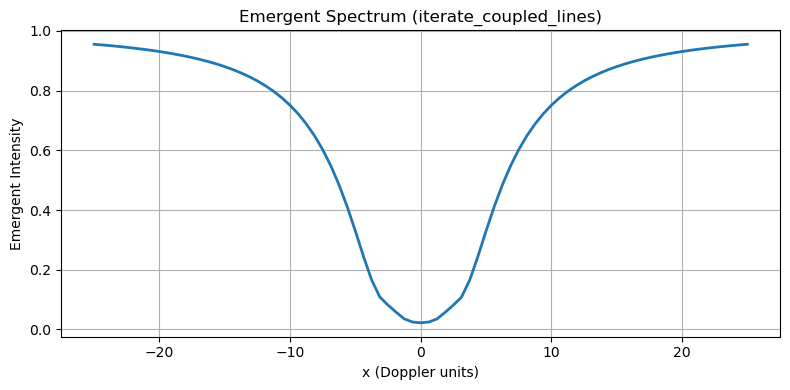

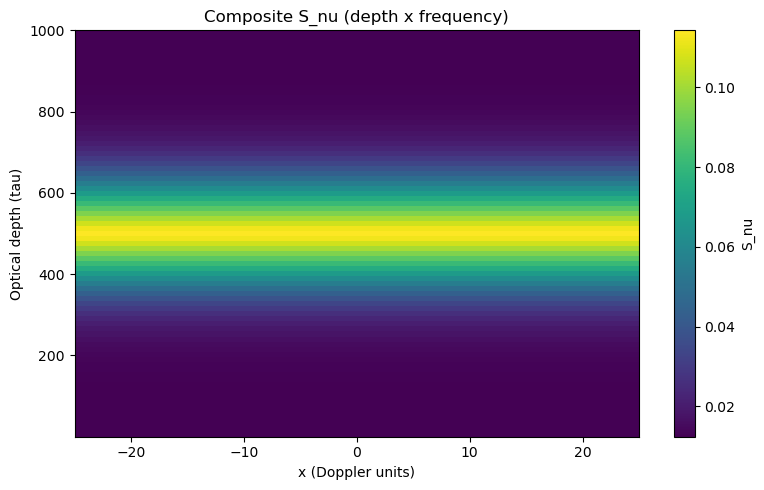

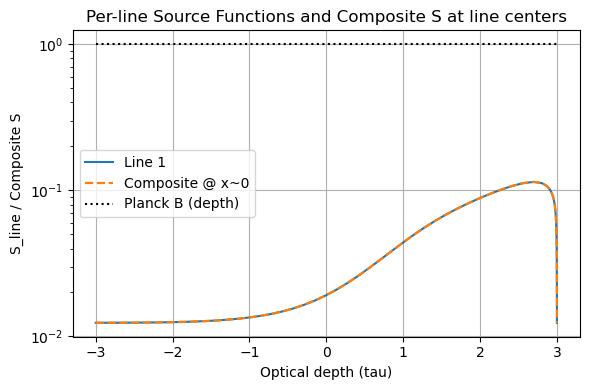

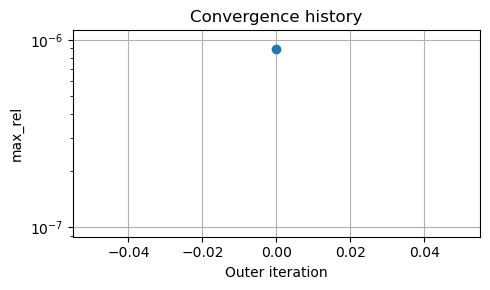

Line 1 phi normalization (sum phi*xw): 1


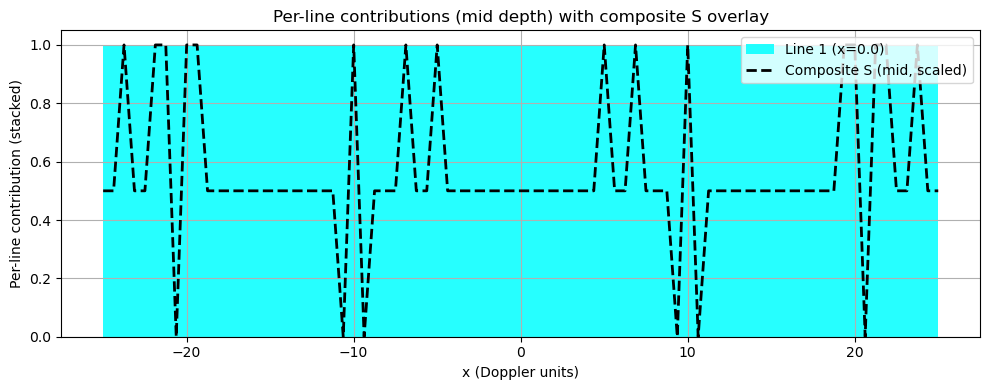

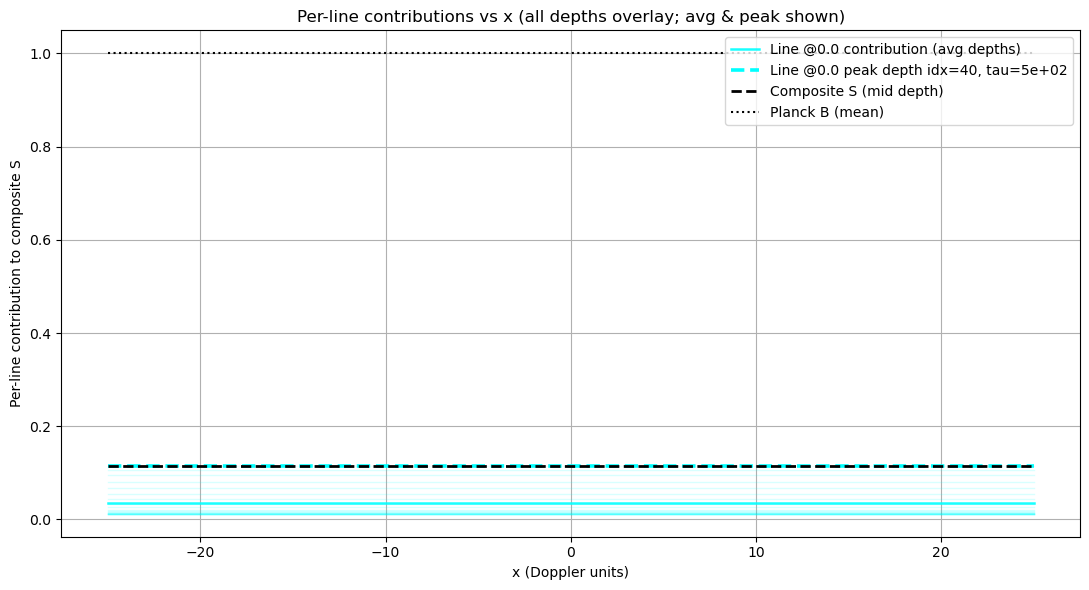

In [6]:
result_one = slab_one_line.iterate_coupled_lines(lines_one, max_iter=2000, tol=1e-6, verbose=False)
v2.plot_help(slab_one_line, lines_one, result=result_one, save_prefix=None, show=True)
result_one_bc1 = iterate_coupled_lines_bc1(slab_one_line, lines_one, max_iter=2000, tol=1e-6, verbose=False)
v2.plot_help(slab_one_line, lines_one, result=result_one_bc1, save_prefix=None, show=True)

<h2>2) One line + "weak" second line</h2>
<p>Here, the second line is very weak (k=0.5) and is located at x=2.5, i.e., in the wing of the first line. The source function of the second line is expected to be very close to the Planck function, and thus the composite source function should be very similar to the one-line case.</p>

In [7]:
slab_two_weak = v2.Slab(ND, tau_max, epsilon, B, H)
line_two_1 = v2.Slab.Line(81, line_center=0.0, a=0.1, k=1.0, slab_in=slab_two_weak)
line_two_2 = v2.Slab.Line(81, line_center=2.5, a=0.1, k=0.5, slab_in=slab_two_weak)
lines_two = [line_two_1, line_two_2]
slab_two_weak.global_x_grid(lines_two)
line_two_1.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_two_weak.x_values)
line_two_2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_two_weak.x_values)

  6%|▌         | 56/1000 [00:01<00:17, 54.20it/s]


Convergence achieved after 56 iterations with max dS = 8.10e-07


  6%|▌         | 55/1000 [00:00<00:16, 58.09it/s]

Convergence achieved after 55 iterations with max dS = 9.97e-07


 52%|█████▏    | 1048/2000 [00:27<00:24, 38.73it/s]


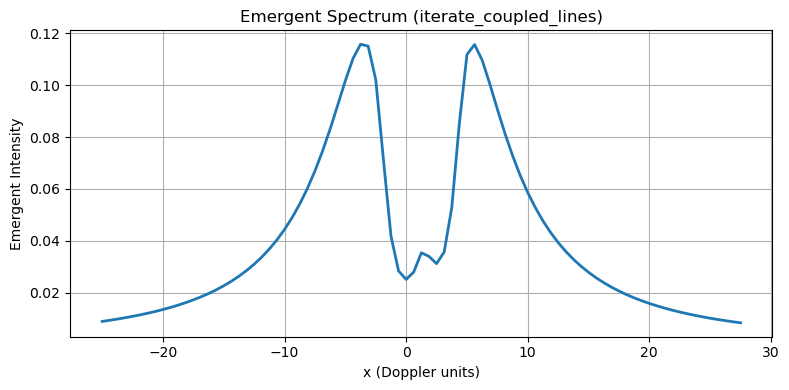

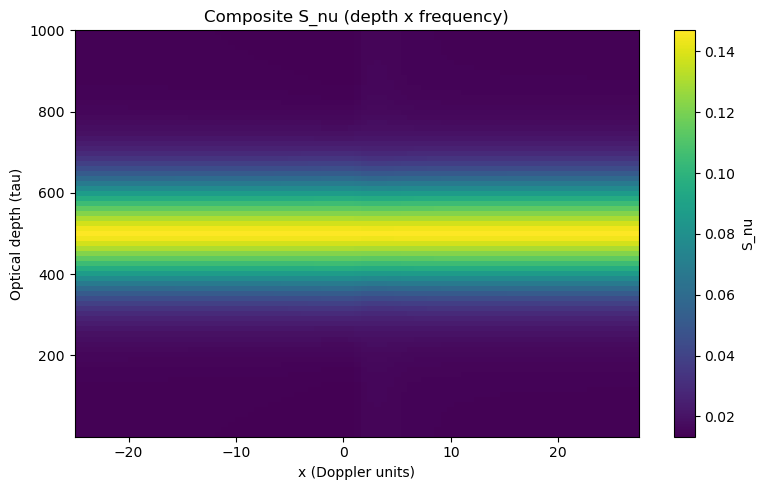

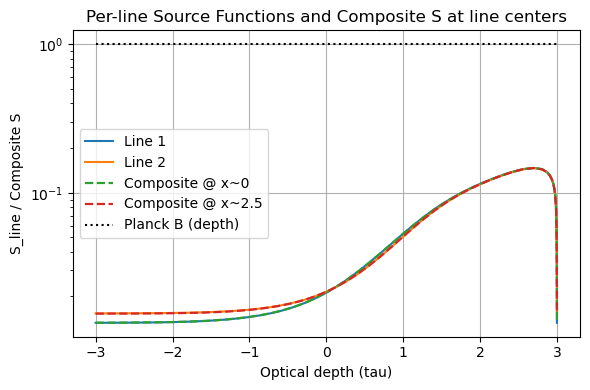

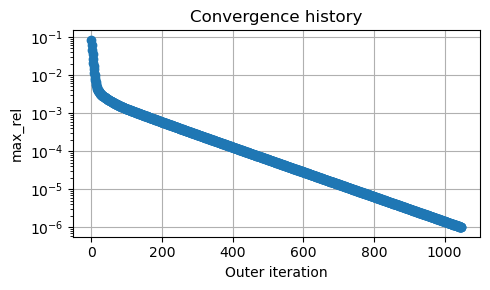

Line 1 phi normalization (sum phi*xw): 1
Line 2 phi normalization (sum phi*xw): 1


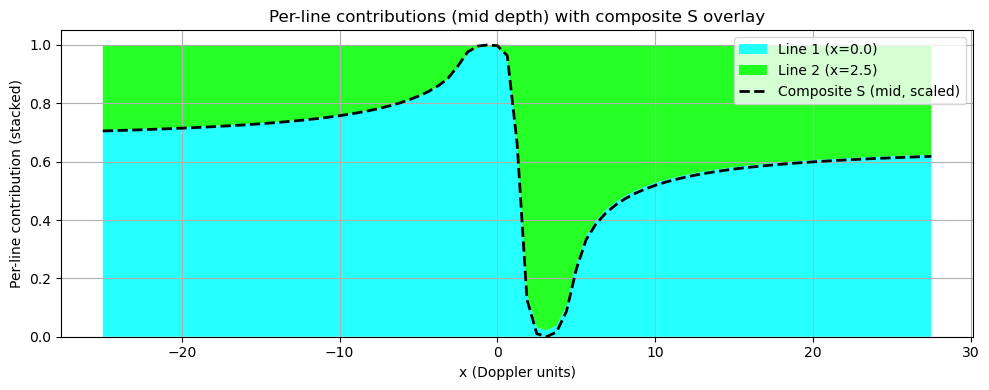

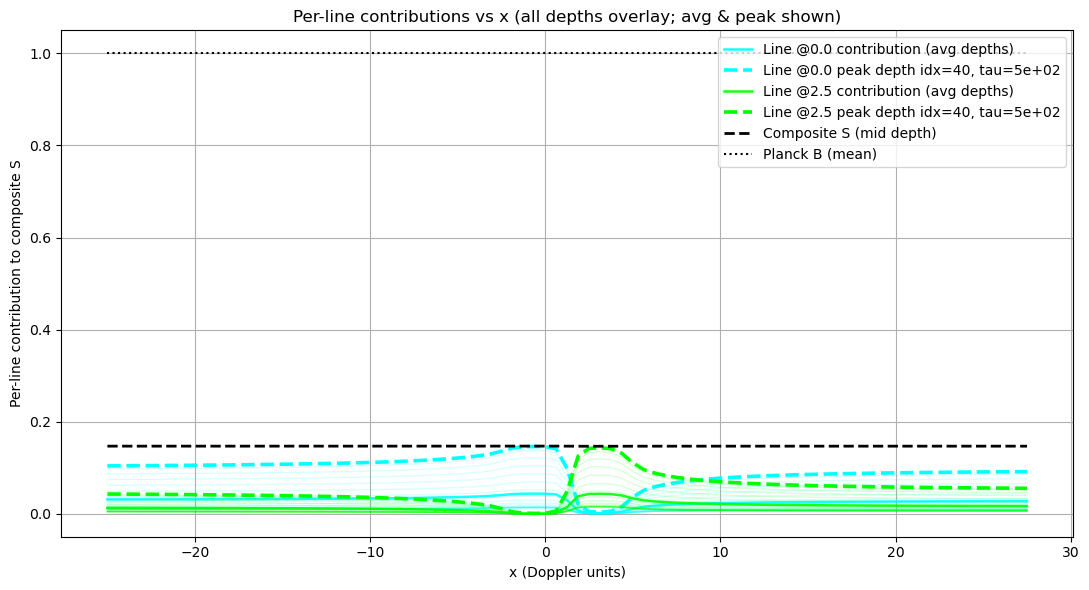

  0%|          | 0/2000 [00:00<?, ?it/s]


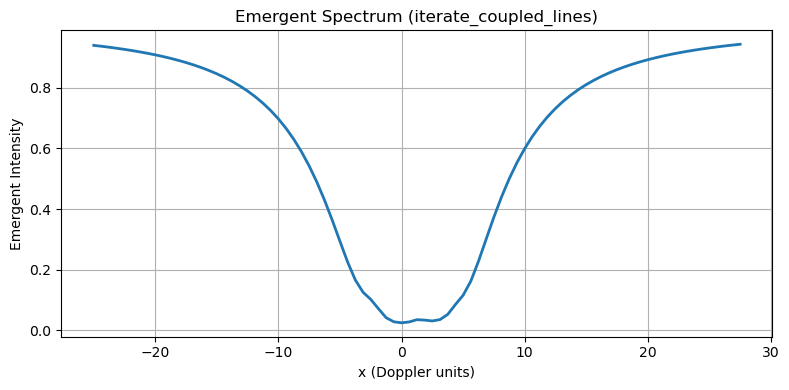

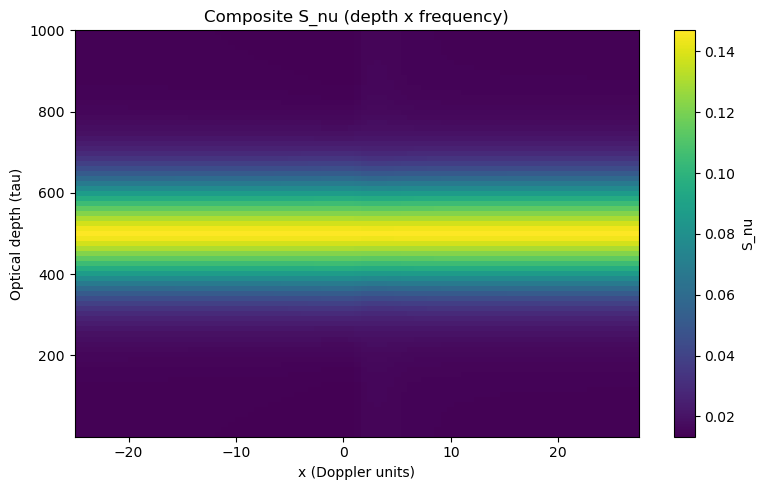

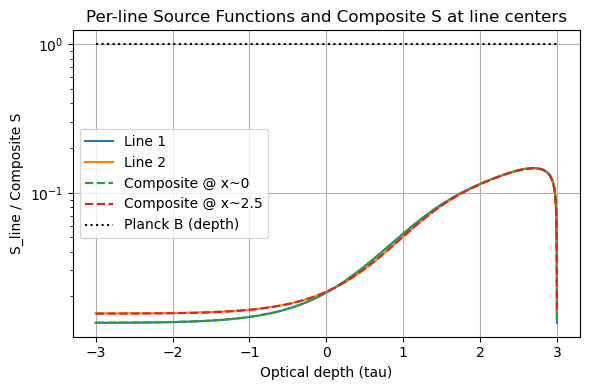

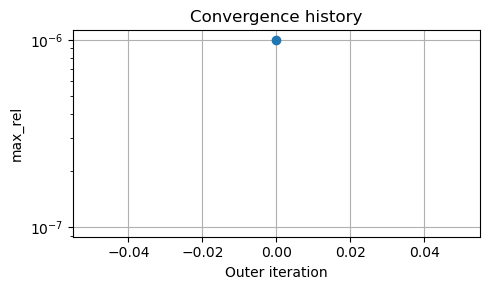

Line 1 phi normalization (sum phi*xw): 1
Line 2 phi normalization (sum phi*xw): 1


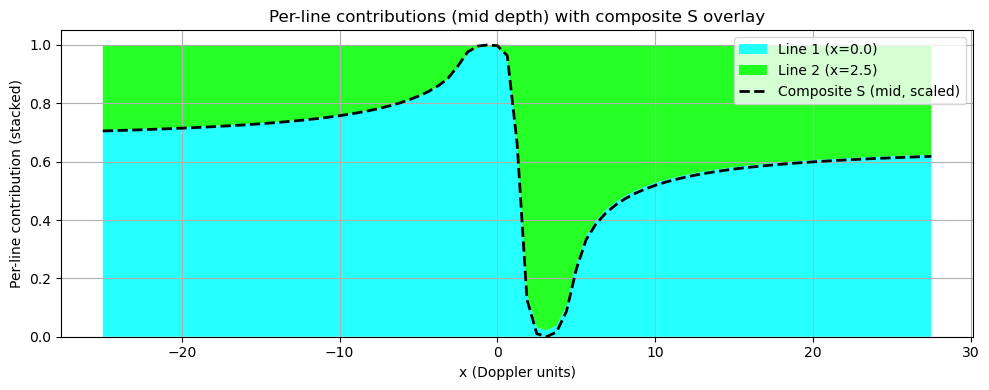

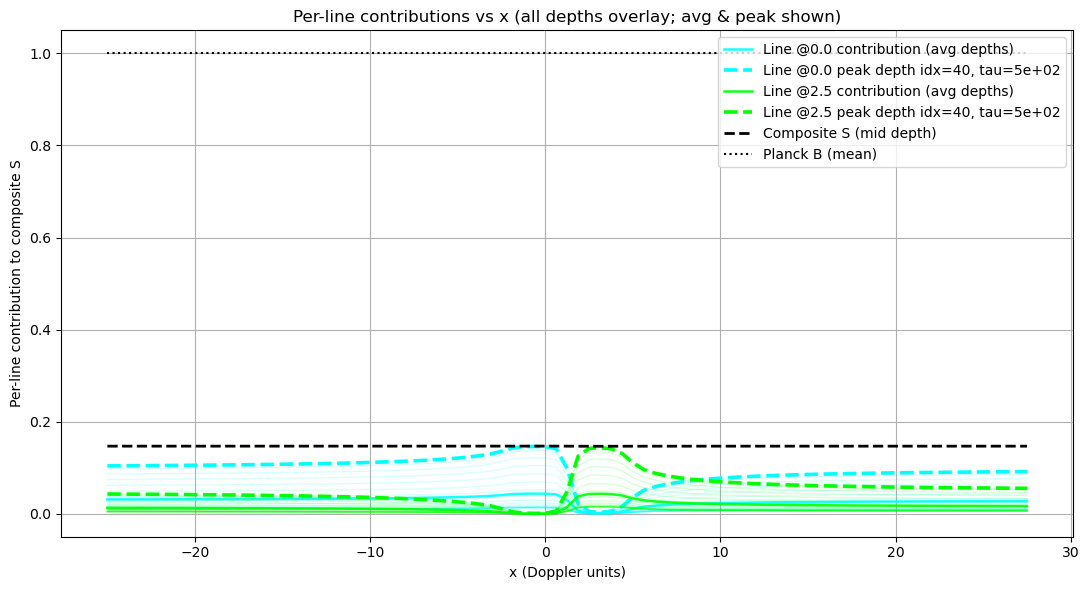

In [8]:
result_two_weak = slab_two_weak.iterate_coupled_lines(lines_two, max_iter=2000, tol=1e-6, verbose=False)
v2.plot_help(slab_two_weak, lines_two, result=result_two_weak, save_prefix=None, show=True)
result_two_weak_bc1 = iterate_coupled_lines_bc1(slab_two_weak, lines_two, max_iter=2000, tol=1e-6, verbose=False)
v2.plot_help(slab_two_weak, lines_two, result=result_two_weak_bc1, save_prefix=None, show=True)

<h2>3) Two line of comparable strength, but well separated</h2>
<p>Here, the second line is of comparable strength (k=1.0) and is located at x = 25.0, i.e., in the far wing of the first line. The source function of the second line is expected to be significantly different from the Planck function, and thus the composite source function should show a significant deviation from the one-line case.</p>

In [9]:
slab_three_ws = v2.Slab(ND, tau_max, epsilon, B, H)
line_three_1 = v2.Slab.Line(81, line_center=-20.0, a=0.2, k=1.0, slab_in=slab_three_ws)
line_three_2 = v2.Slab.Line(81, line_center=25.0, a=0.2, k=1.0, slab_in=slab_three_ws)
lines_three = [line_three_1, line_three_2]
slab_three_ws.global_x_grid(lines_three)
line_three_1.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_three_ws.x_values)
line_three_2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_three_ws.x_values)

  5%|▍         | 49/1000 [00:01<00:28, 33.07it/s]


Convergence achieved after 49 iterations with max dS = 8.20e-07


  5%|▍         | 49/1000 [00:01<00:29, 32.27it/s]

Convergence achieved after 49 iterations with max dS = 8.20e-07


 28%|██▊       | 551/2000 [00:24<01:03, 22.69it/s]


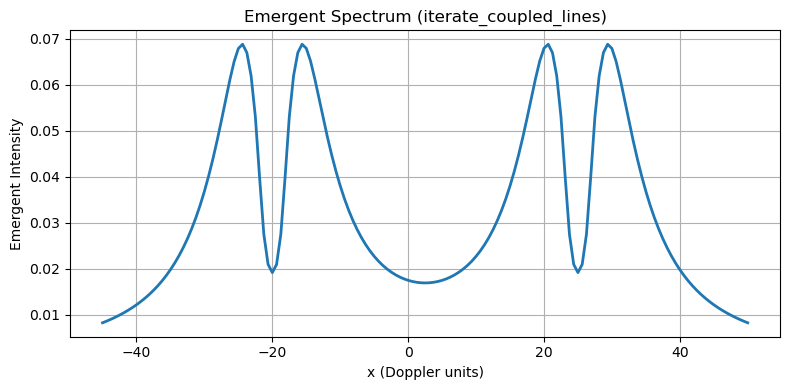

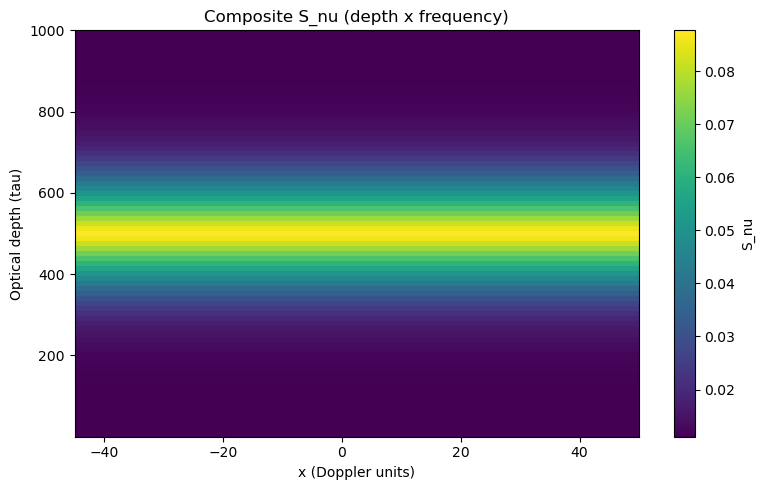

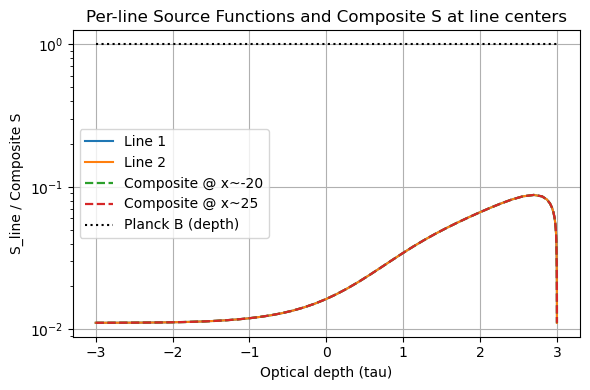

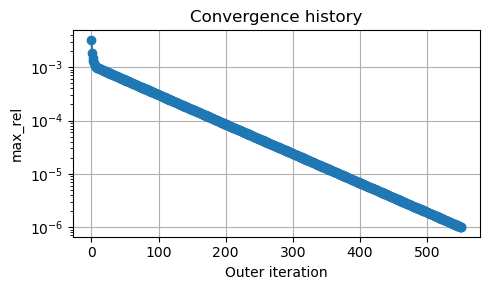

Line 1 phi normalization (sum phi*xw): 1
Line 2 phi normalization (sum phi*xw): 1


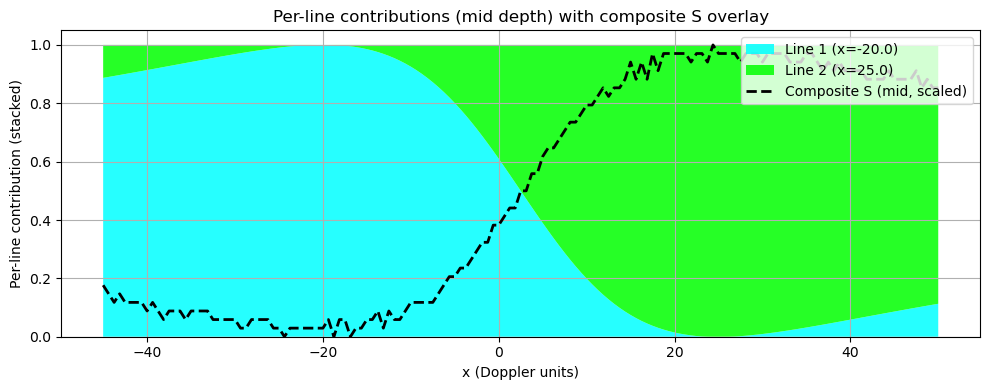

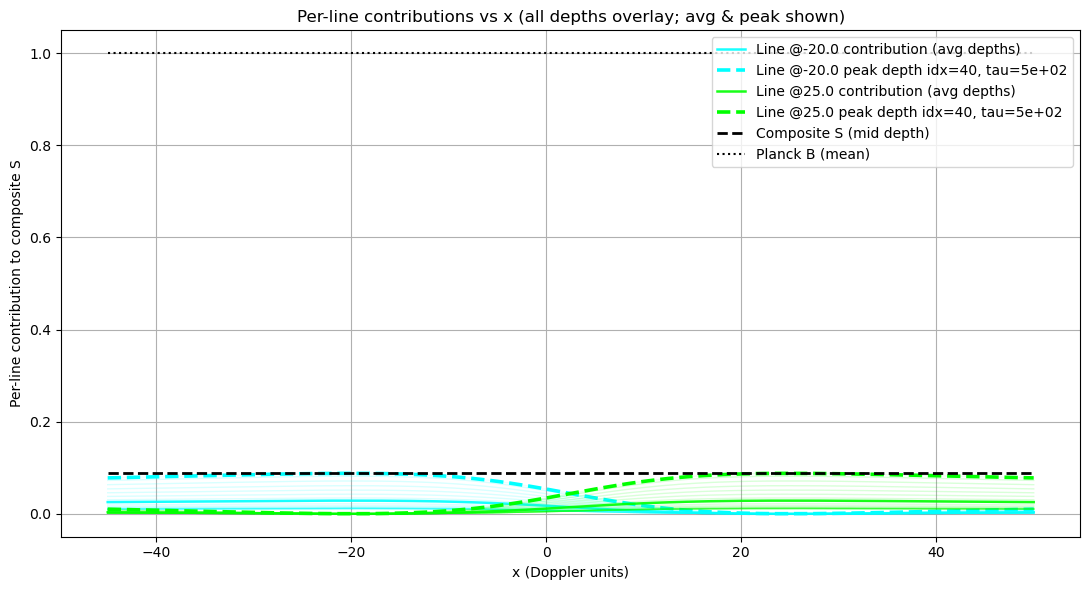

  0%|          | 0/2000 [00:00<?, ?it/s]


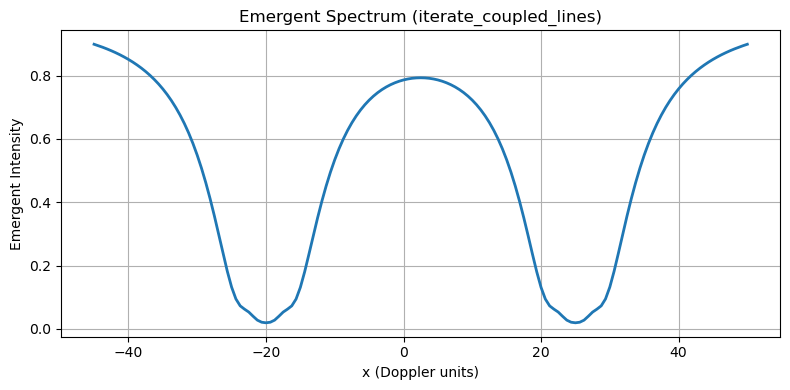

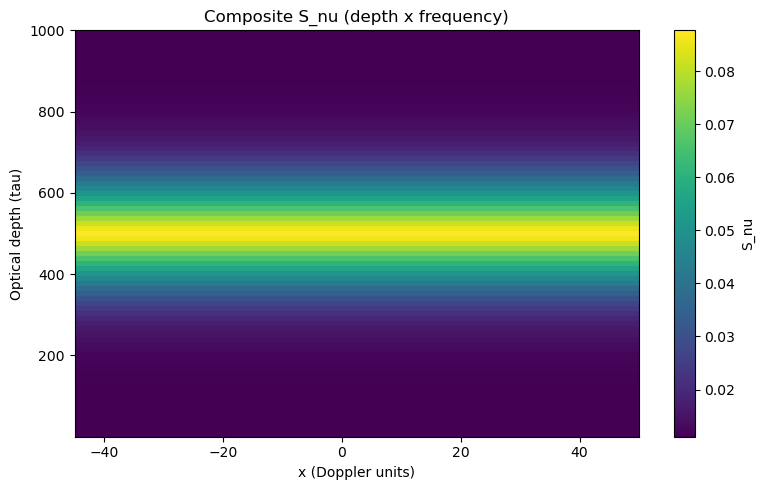

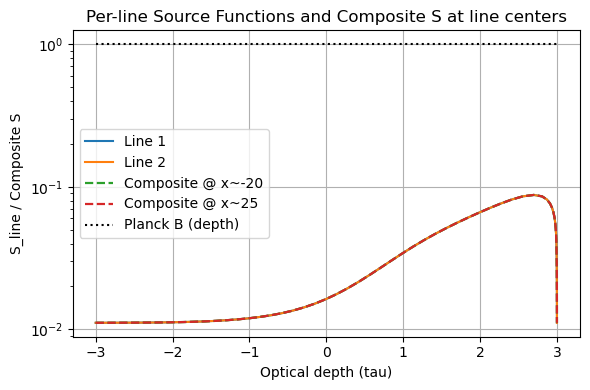

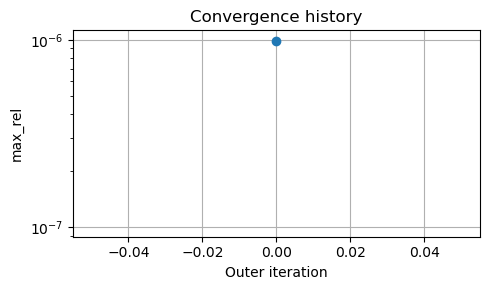

Line 1 phi normalization (sum phi*xw): 1
Line 2 phi normalization (sum phi*xw): 1


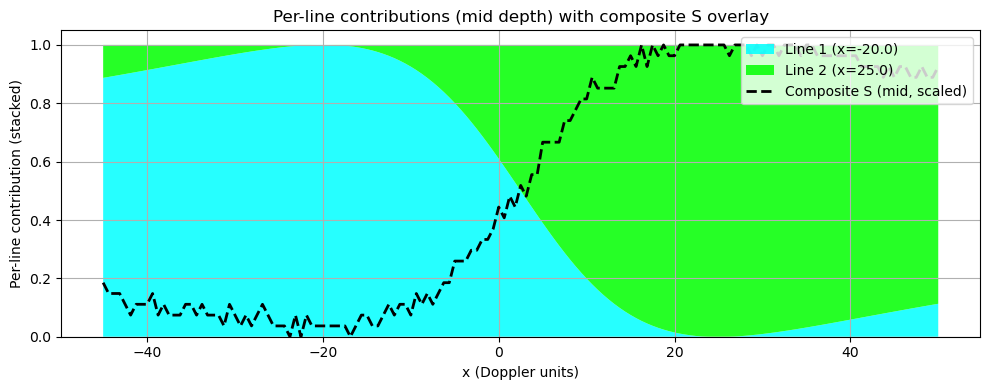

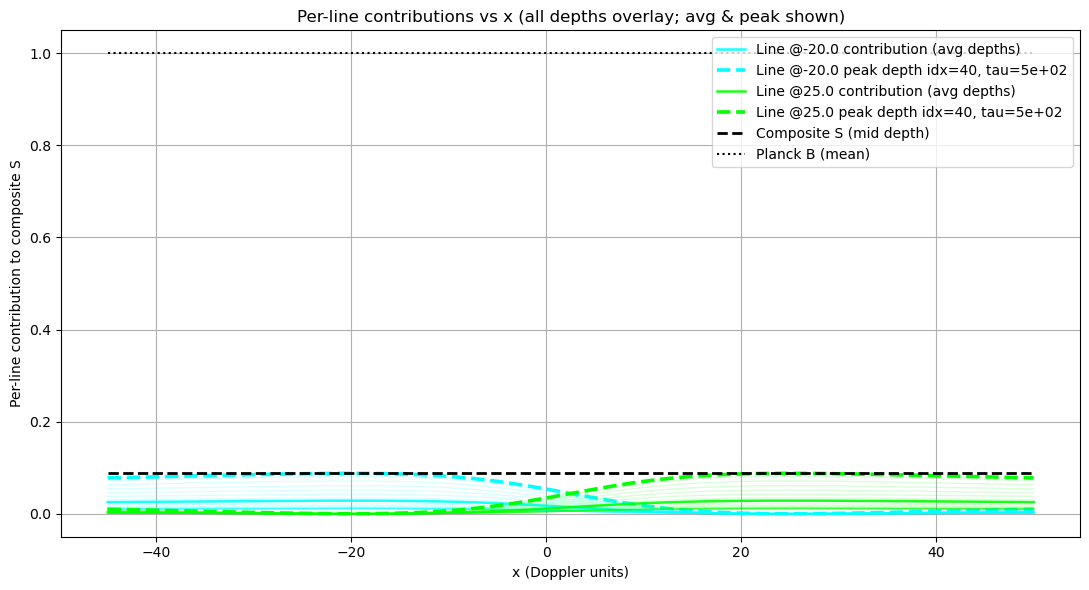

In [10]:
result_three_ws = slab_three_ws.iterate_coupled_lines(lines_three, max_iter=2000, tol=1e-6, verbose=False)
v2.plot_help(slab_three_ws, lines_three, result=result_three_ws, save_prefix=None, show=True)
result_three_ws_bc1 = iterate_coupled_lines_bc1(slab_three_ws, lines_three, max_iter=2000, tol=1e-6, verbose=False)
v2.plot_help(slab_three_ws, lines_three, result=result_three_ws_bc1, save_prefix=None, show=True)

<h2>4) Two very different lines, well separated</h2>
<p>Well separated as in the previous example, but with different damping parameters and strengths.</p>

In [11]:
slab_four_diff = v2.Slab(ND, tau_max, epsilon, B, H)
line_four_1 = v2.Slab.Line(81, line_center=-20.0, a=0.2, k=1.0, slab_in=slab_four_diff)
line_four_2 = v2.Slab.Line(81, line_center=25.0, a=0.3, k=4.0, slab_in=slab_four_diff)
lines_four = [line_four_1, line_four_2]
slab_four_diff.global_x_grid(lines_four)
line_four_1.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_four_diff.x_values)
line_four_2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_four_diff.x_values)

  5%|▍         | 49/1000 [00:01<00:30, 31.11it/s]


Convergence achieved after 49 iterations with max dS = 8.20e-07


  5%|▍         | 49/1000 [00:01<00:30, 31.39it/s]

Convergence achieved after 49 iterations with max dS = 9.41e-07


 51%|█████     | 1022/2000 [00:43<00:42, 23.27it/s]


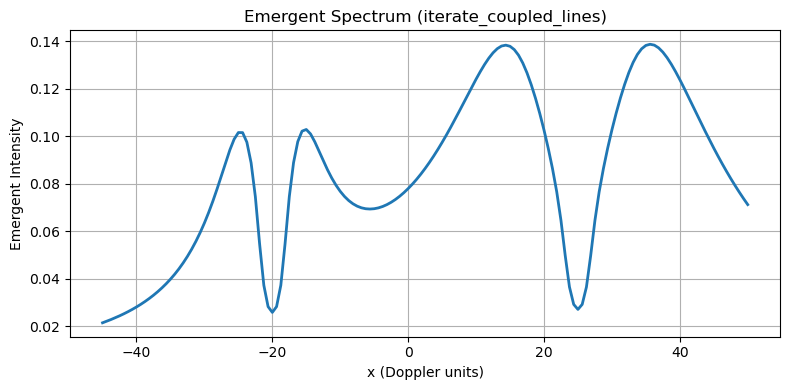

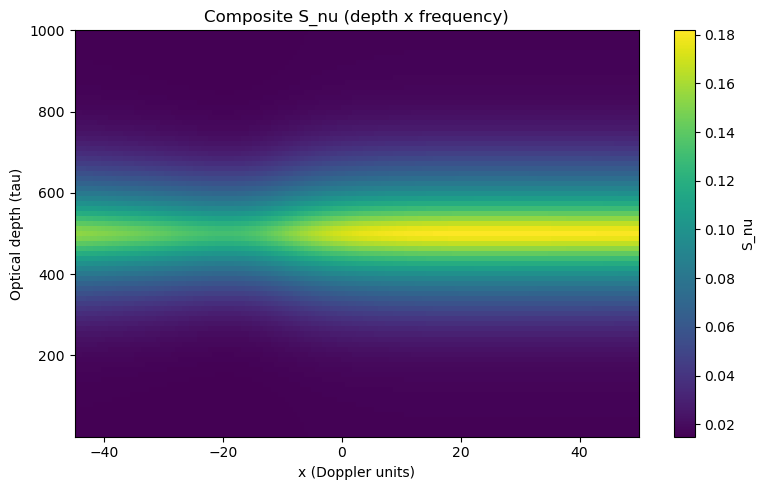

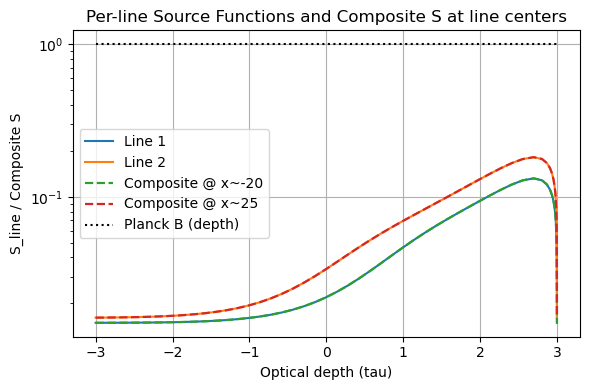

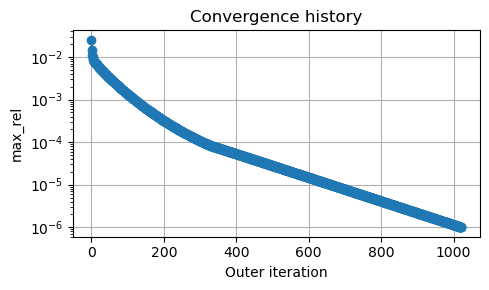

Line 1 phi normalization (sum phi*xw): 1
Line 2 phi normalization (sum phi*xw): 1


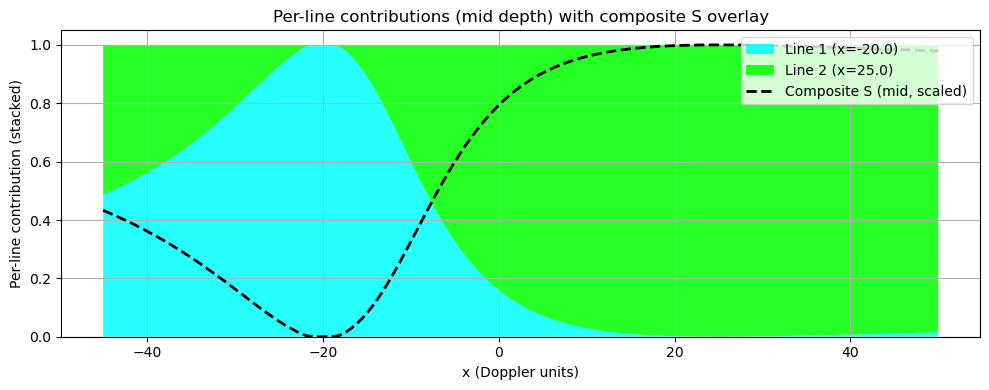

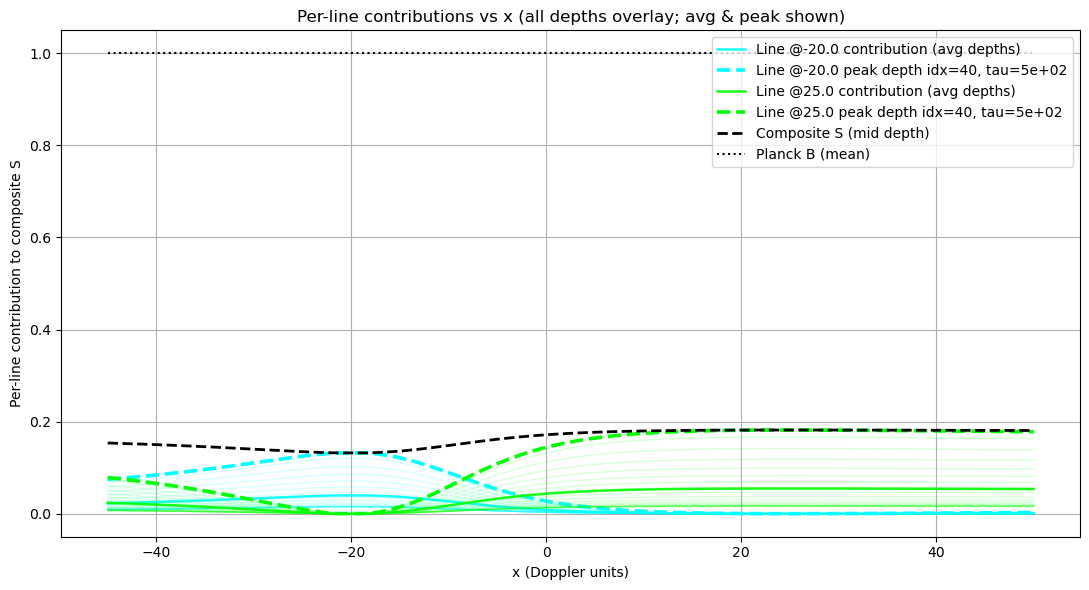

  0%|          | 0/2000 [00:00<?, ?it/s]


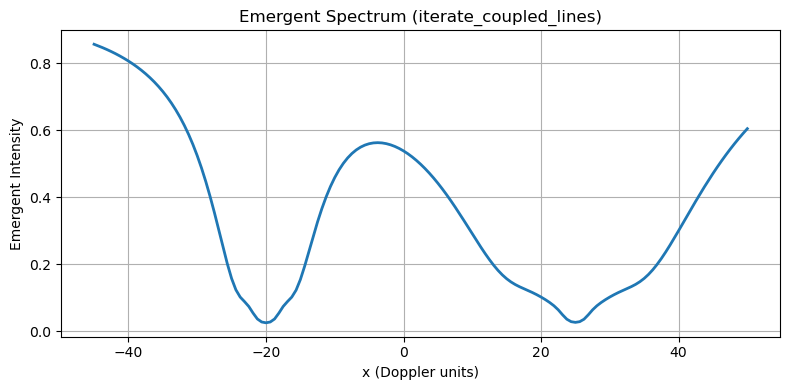

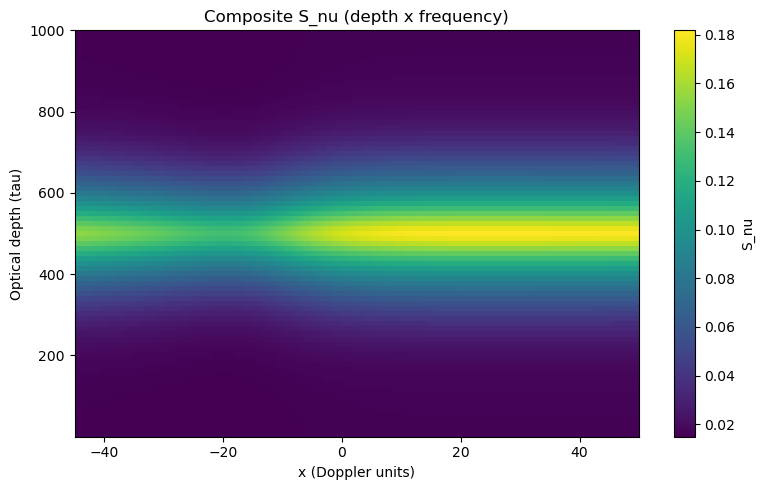

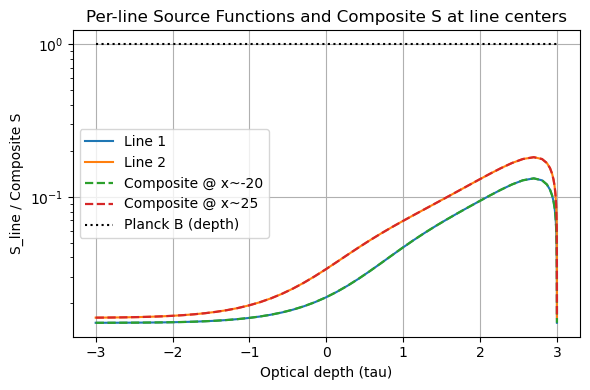

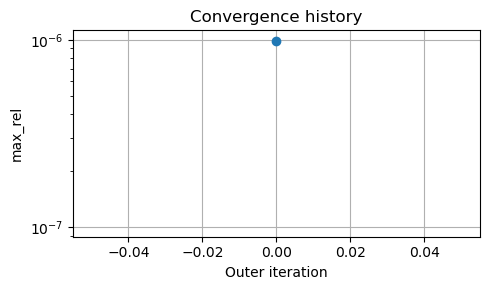

Line 1 phi normalization (sum phi*xw): 1
Line 2 phi normalization (sum phi*xw): 1


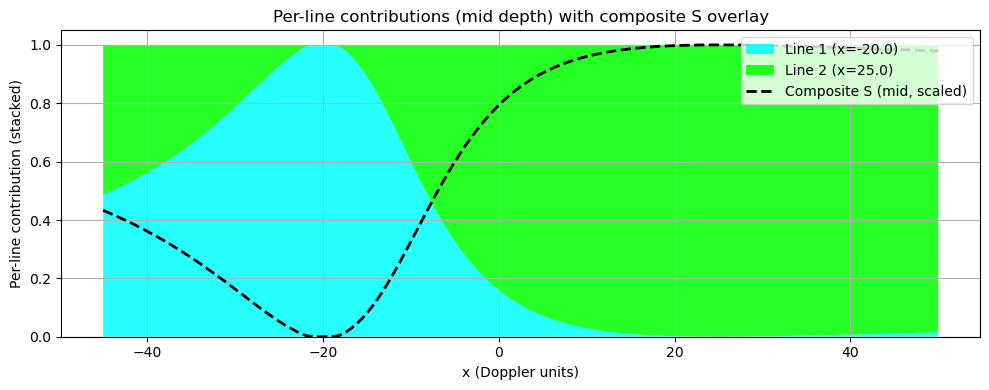

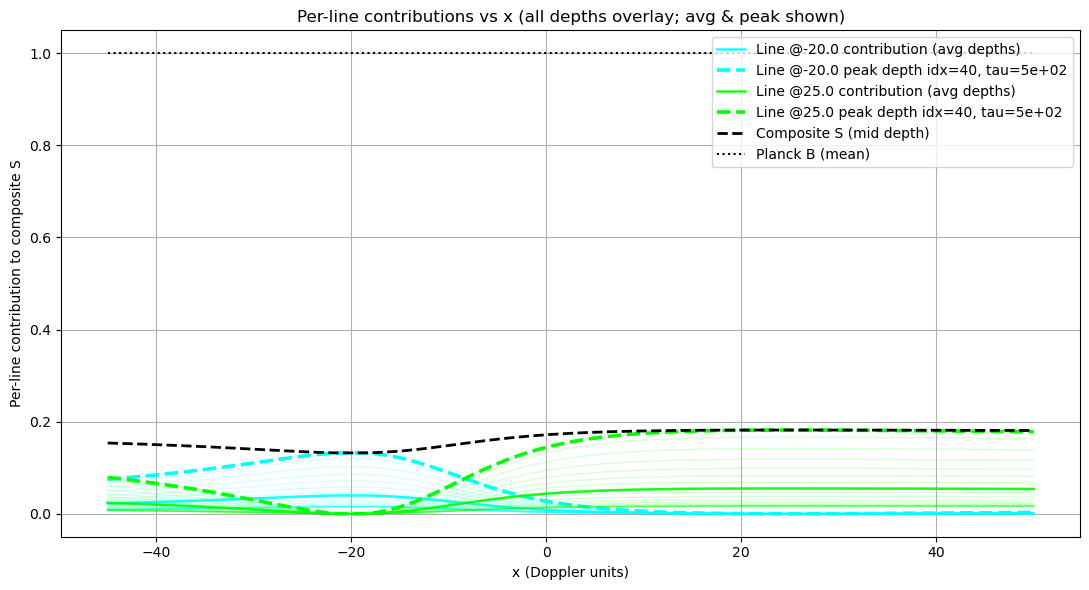

In [12]:
result_four_diff = slab_four_diff.iterate_coupled_lines(lines_four, max_iter=2000, tol=1e-6, verbose=False)
v2.plot_help(slab_four_diff, lines_four, result=result_four_diff, save_prefix=None, show=True)
result_four_diff_bc1 = iterate_coupled_lines_bc1(slab_four_diff, lines_four, max_iter=2000, tol=1e-6, verbose=False)
v2.plot_help(slab_four_diff, lines_four, result=result_four_diff_bc1, save_prefix=None, show=True)

result_one
[('result_one', 'result_one_bc1')]
result_two_weak
[('result_one', 'result_one_bc1'), ('result_two_weak', 'result_two_weak_bc1')]
result_three_ws
[('result_one', 'result_one_bc1'), ('result_two_weak', 'result_two_weak_bc1'), ('result_three_ws', 'result_three_ws_bc1')]
result_four_diff
[('result_one', 'result_one_bc1'), ('result_two_weak', 'result_two_weak_bc1'), ('result_three_ws', 'result_three_ws_bc1'), ('result_four_diff', 'result_four_diff_bc1')]


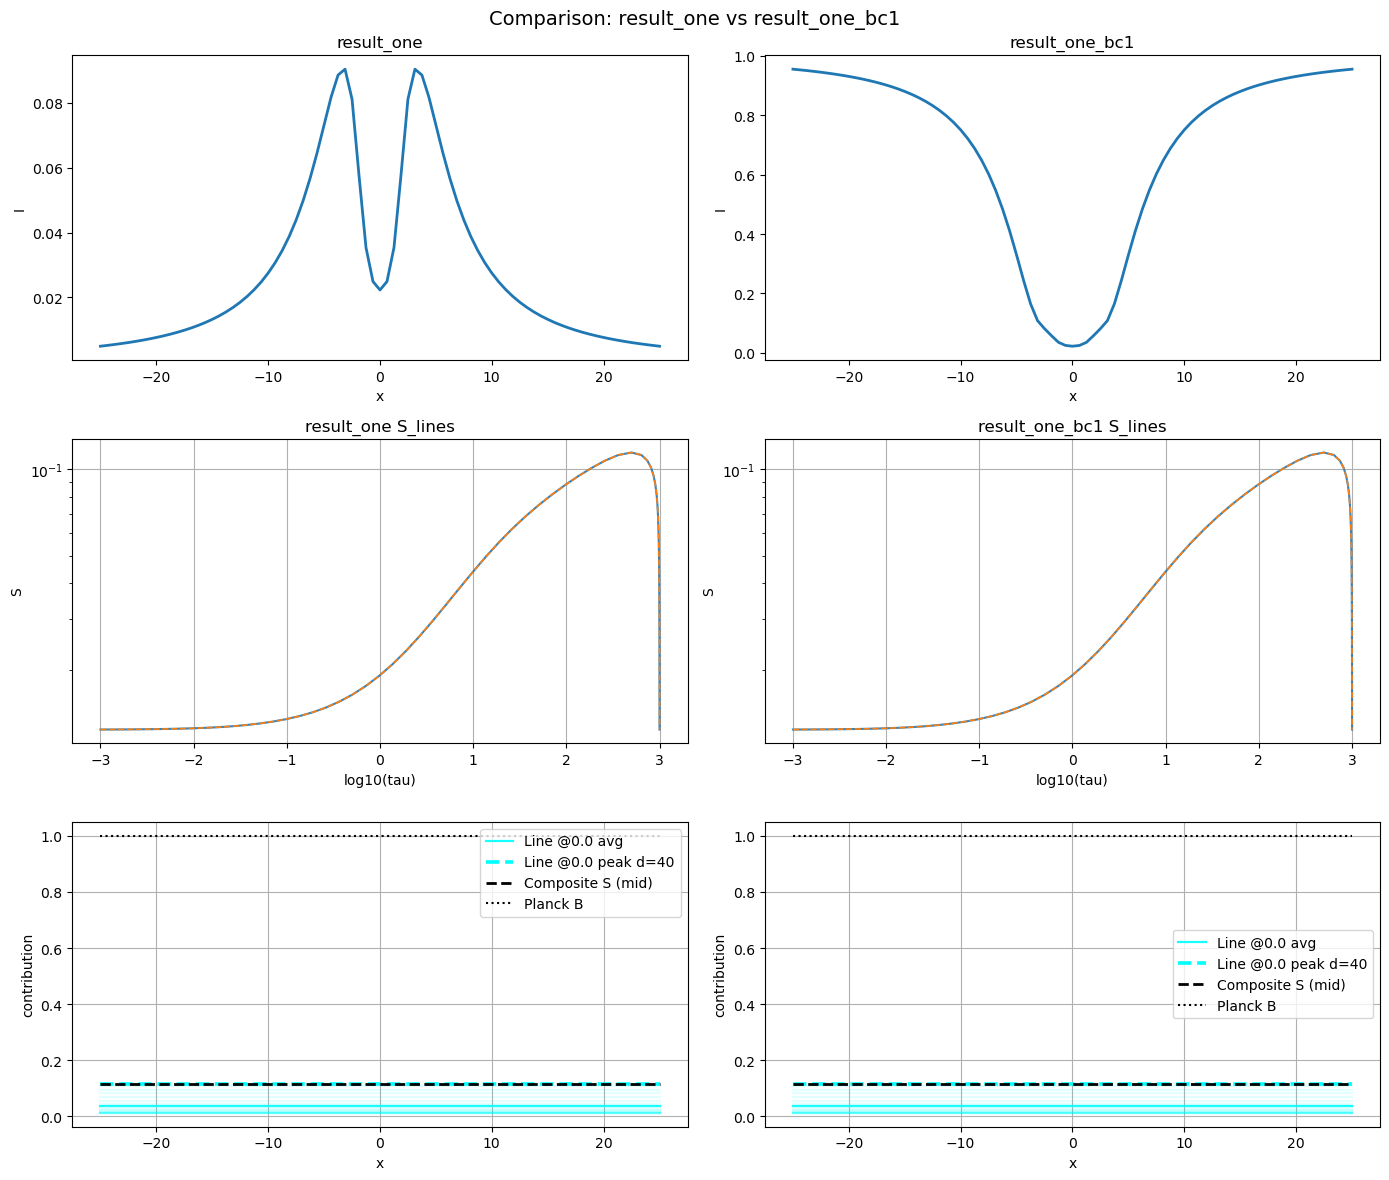

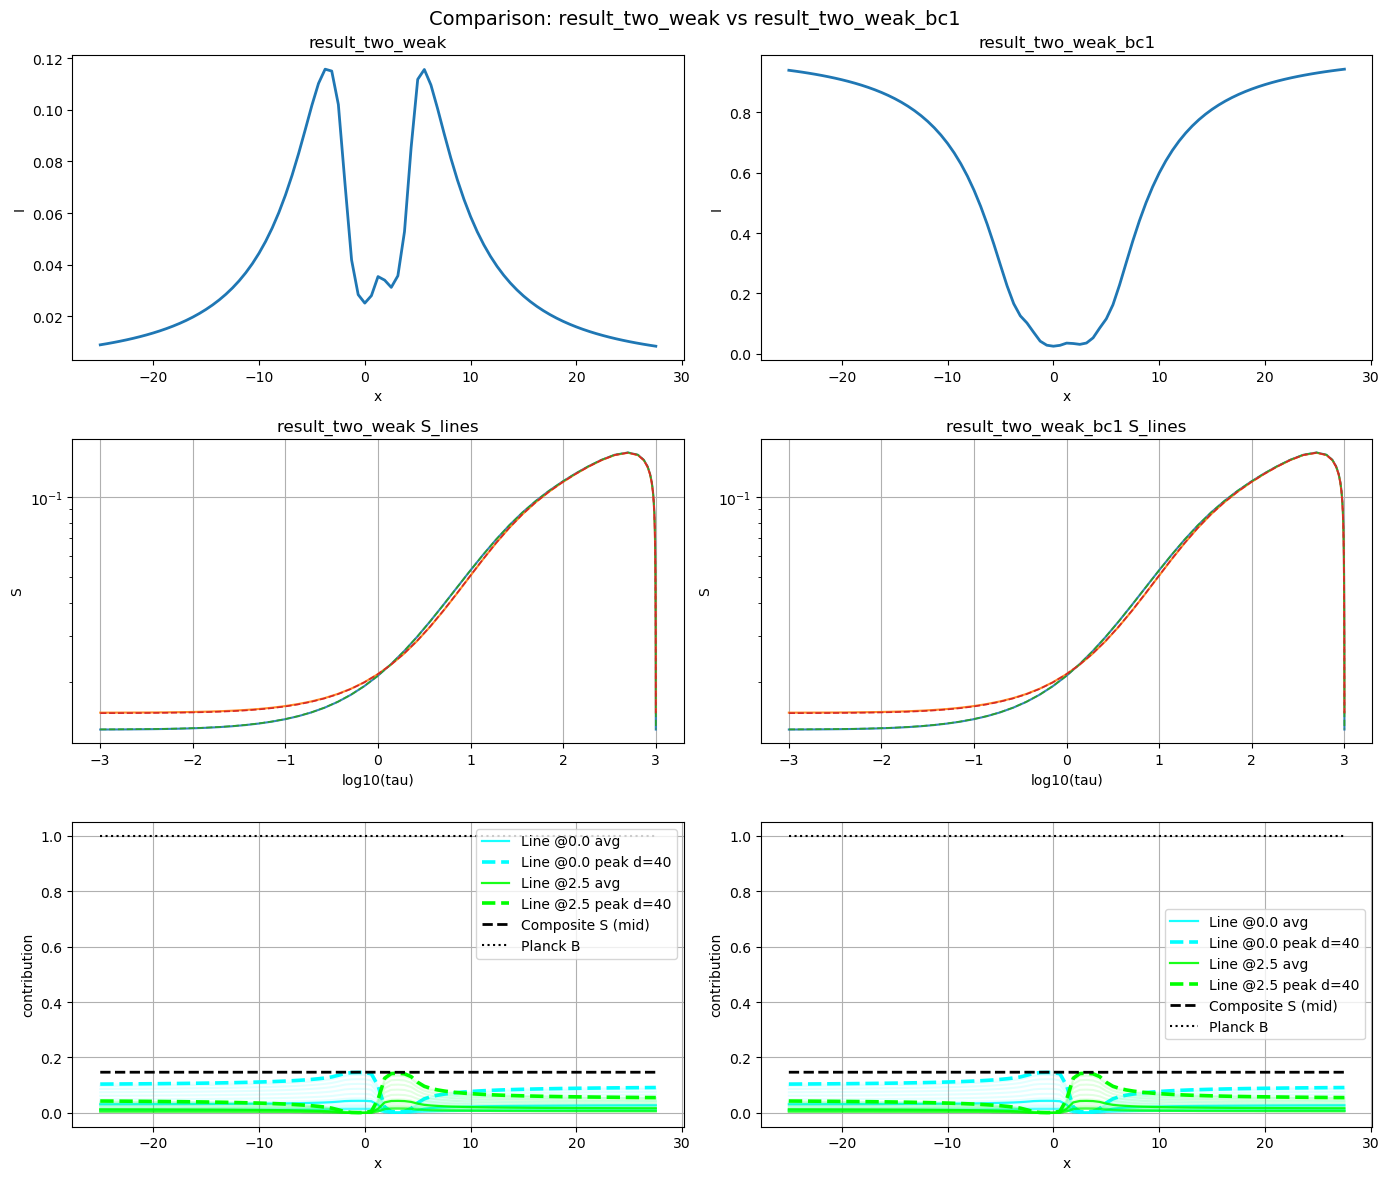

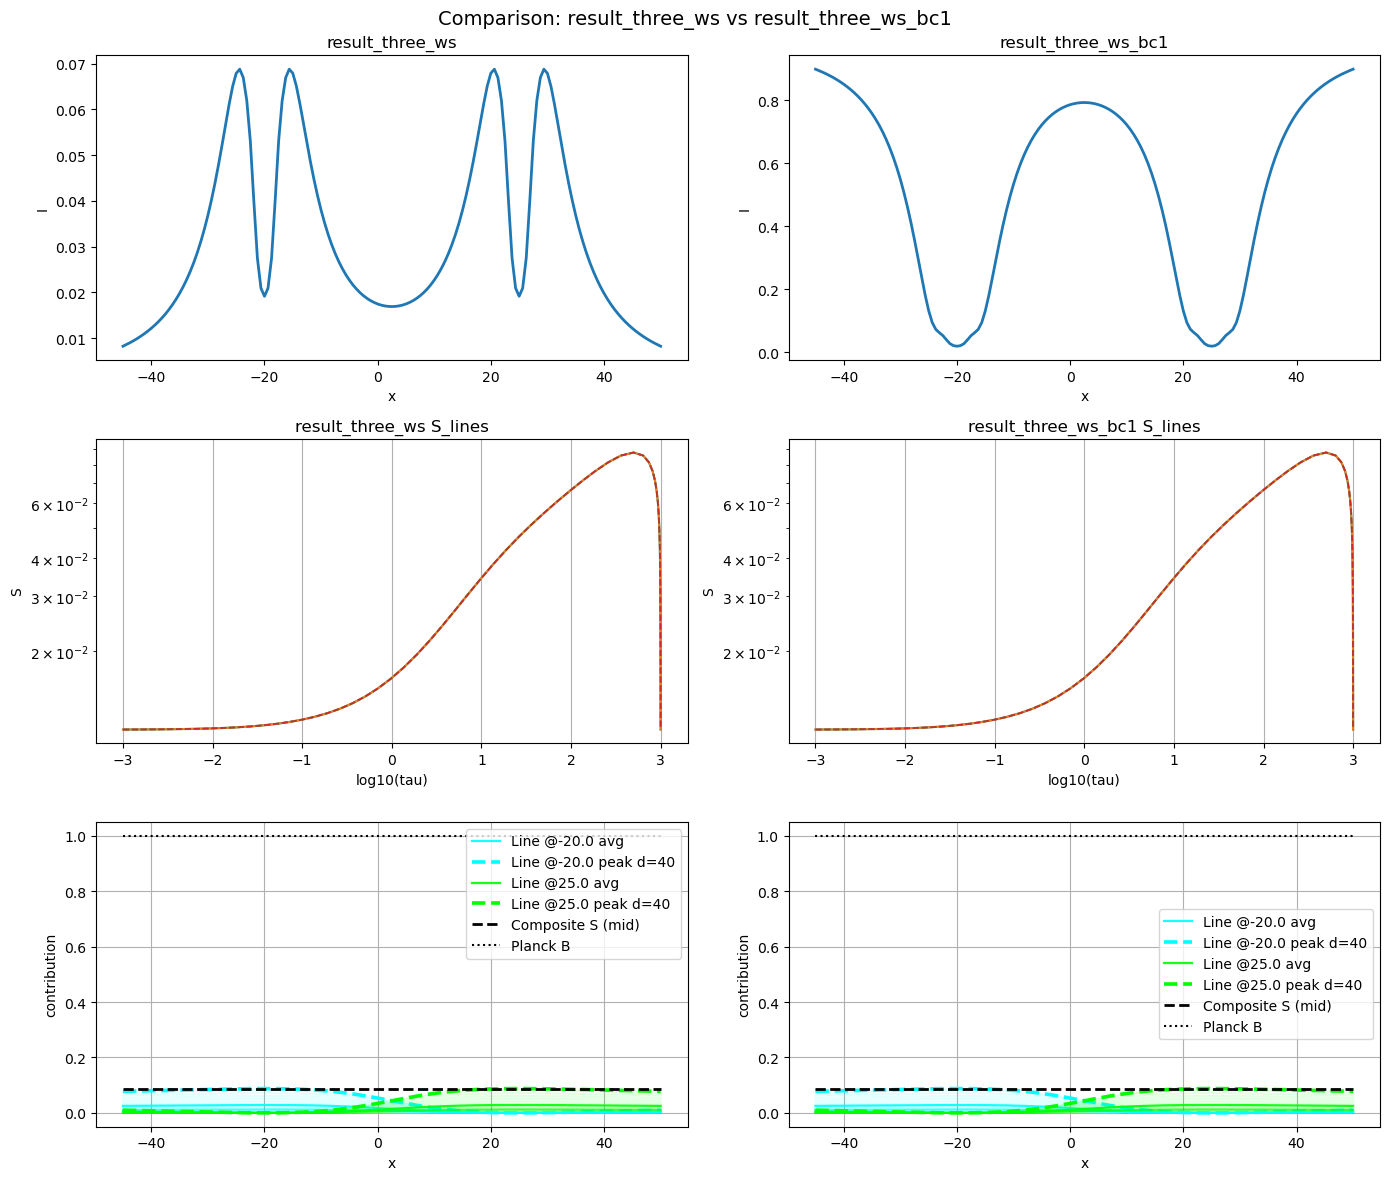

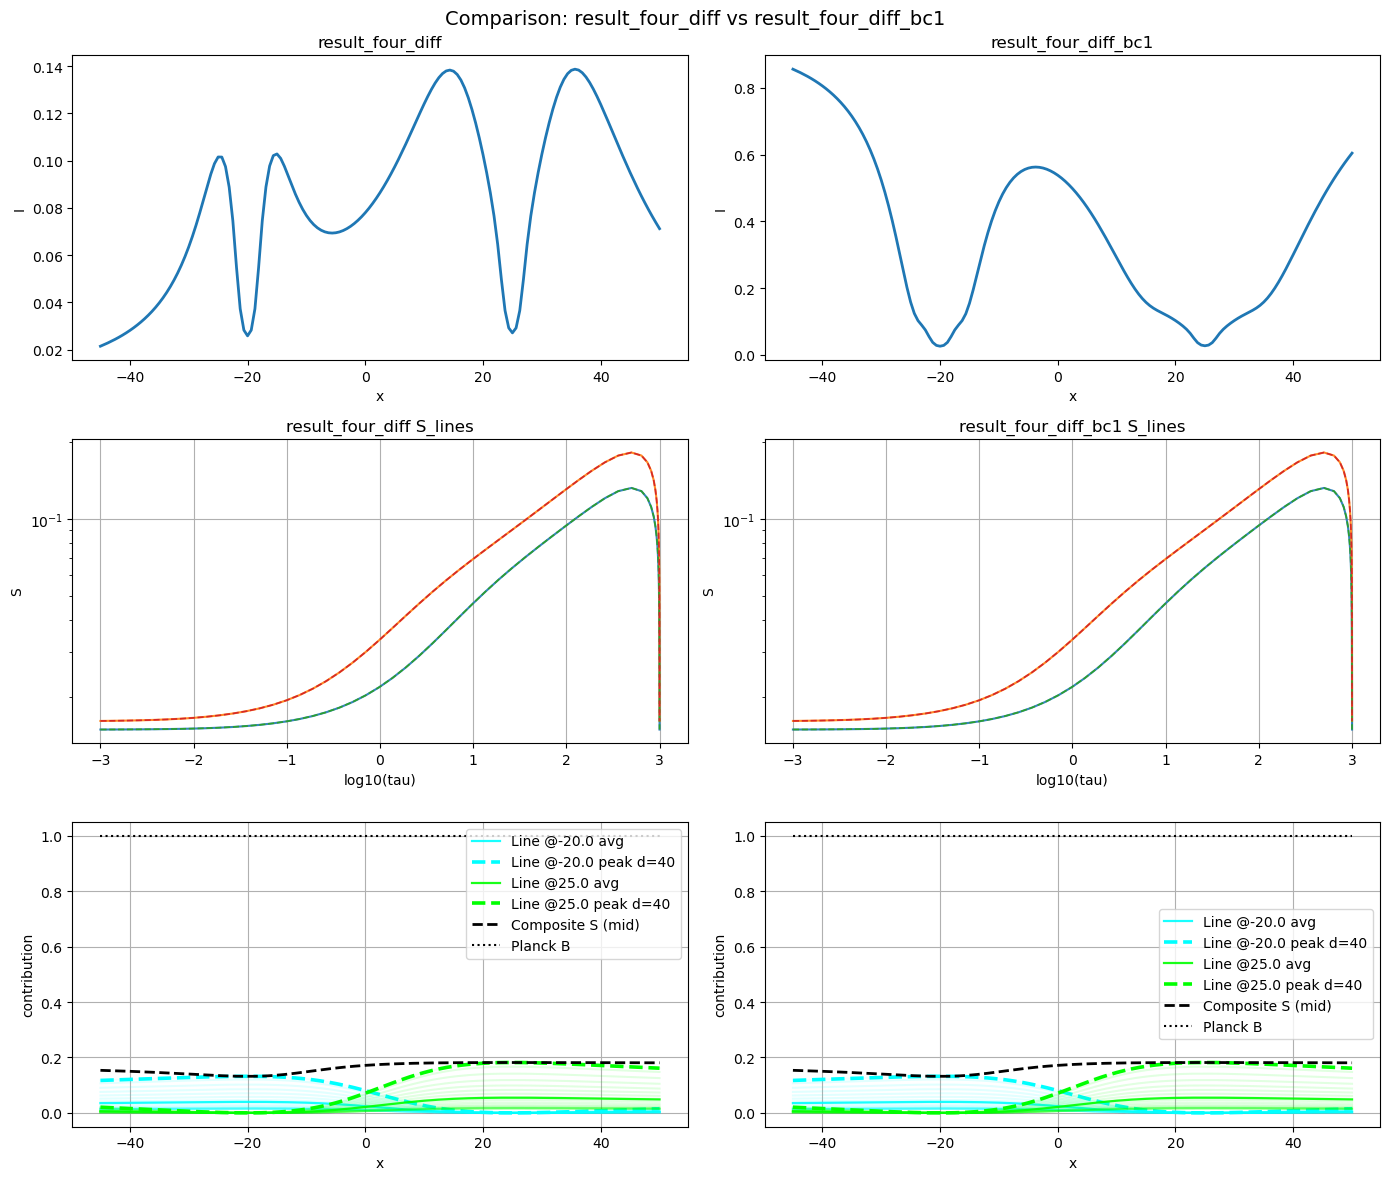

In [14]:
# Compare iterate_coupled_lines vs bc1 for all studied cases
import matplotlib.pyplot as plt
import numpy as np
import SLab_linev2 as v2
vars_dict = globals()
# explicit list of case base names used in this notebook
case_bases = ['result_one', 'result_two_weak', 'result_three_ws', 'result_four_diff']
pairs = []
for base in case_bases:
    print(base)
    bc1 = base + '_bc1'
    if base in vars_dict and bc1 in vars_dict:
        pairs.append((base, bc1))
    print(pairs)
# fallback: discover any pairs dynamically if explicit list found none
if len(pairs) == 0:
    for name in list(vars_dict.keys()):
        if name.endswith('_bc1'):
            base = name[:-4]
            if base in vars_dict:
                pairs.append((base, base + '_bc1'))
        print(pairs)
if len(pairs) == 0:
    print('No result pairs found to compare. Run the case cells first.')
for base, bc1 in pairs:
    resA = vars_dict[base]
    resB = vars_dict[bc1]
    # find a matching slab instance by shape or fallback to any Slab
    slab_candidates = [v for v in vars_dict.values() if isinstance(v, v2.Slab)]
    slab = None
    for s in slab_candidates:
        try:
            if hasattr(s, 'x_values') and s.x_values is not None and len(s.x_values) == len(resA.get('I_emergent', [])) and hasattr(s, 'tau') and len(s.tau) == len(resA.get('S_lines', [[],])[0]):
                slab = s; break
        except Exception:
            pass
    if slab is None and len(slab_candidates) > 0:
        slab = slab_candidates[0]
    x = slab.x_values if (slab is not None and getattr(slab, 'x_values', None) is not None) else np.arange(len(resA.get('I_emergent', [])))
    tau = slab.tau if (slab is not None and getattr(slab, 'tau', None) is not None) else np.arange(len(resA.get('S_lines', [[],])[0]))
    S_nuA = resA.get('S_nu', None); I_A = resA.get('I_emergent', None); S_linesA = resA.get('S_lines', None)
    S_nuB = resB.get('S_nu', None); I_B = resB.get('I_emergent', None); S_linesB = resB.get('S_lines', None)
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    # Row 0: emergent spectrum
    ax = axes[0, 0];
    if I_A is not None:
        ax.plot(x, I_A, lw=2)
    ax.set_title(base); ax.set_xlabel('x'); ax.set_ylabel('I')
    ax = axes[0, 1];
    if I_B is not None:
        ax.plot(x, I_B, lw=2)
    ax.set_title(bc1); ax.set_xlabel('x'); ax.set_ylabel('I')
    # Row1: per-line S vs tau (overlay composite if available)
    ax = axes[1, 0]
    if S_linesA is not None:
        for i, S in enumerate(S_linesA):
            ax.semilogy(np.log10(tau), S, label=f'Line {i+1}', alpha=0.9)
        # overlay composite S at each line center if available and slab present
        if S_nuA is not None and slab is not None:
            # try to find corresponding lines list among globals (same slab)
            candidate_lines = [v for v in vars_dict.values() if isinstance(v, list) and len(v) == len(S_linesA) and all(hasattr(el, 'line_center') for el in v)]
            lines_list = None
            for L in candidate_lines:
                if all(getattr(el, 'slab_in', None) is slab for el in L):
                    lines_list = L; break
            if lines_list is None:
                # fallback: place composite curves without label
                for i_line in range(min(len(S_linesA), S_nuA.shape[1])):
                    ax.semilogy(np.log10(tau), S_nuA[:, i_line], linestyle='--', lw=1.2, color='k', alpha=0.8)
            else:
                for i_line, ln in enumerate(lines_list):
                    idx = int(np.argmin(np.abs(x - ln.line_center)))
                    ax.semilogy(np.log10(tau), S_nuA[:, idx], linestyle='--', lw=1.2, label=f'Composite @ {ln.line_center}')
    ax.set_xlabel('log10(tau)'); ax.set_ylabel('S'); ax.set_title(base + ' S_lines'); ax.grid(True)
    ax = axes[1, 1]
    if S_linesB is not None:
        for i, S in enumerate(S_linesB):
            ax.semilogy(np.log10(tau), S, label=f'Line {i+1}', alpha=0.9)
        if S_nuB is not None and slab is not None:
            candidate_lines = [v for v in vars_dict.values() if isinstance(v, list) and len(v) == len(S_linesB) and all(hasattr(el, 'line_center') for el in v)]
            lines_list = None
            for L in candidate_lines:
                if all(getattr(el, 'slab_in', None) is slab for el in L):
                    lines_list = L; break
            if lines_list is None:
                for i_line in range(min(len(S_linesB), S_nuB.shape[1])):
                    ax.semilogy(np.log10(tau), S_nuB[:, i_line], linestyle='--', lw=1.2, color='k', alpha=0.8)
            else:
                for i_line, ln in enumerate(lines_list):
                    idx = int(np.argmin(np.abs(x - ln.line_center)))
                    ax.semilogy(np.log10(tau), S_nuB[:, idx], linestyle='--', lw=1.2, label=f'Composite @ {ln.line_center}')
    ax.set_xlabel('log10(tau)'); ax.set_ylabel('S'); ax.set_title(bc1 + ' S_lines'); ax.grid(True)
    # Row2: per-line contributions vs x (avg & peak)
    def plot_contrib(ax, S_nu, S_lines, slab):
        try:
            # attempt to find a lines list matching this slab in globals
            candidate_lines = [v for v in vars_dict.values() if isinstance(v, list) and len(v) == len(S_lines) and all(hasattr(el, 'line_center') for el in v)]
            lines_list = None
            for L in candidate_lines:
                if all(getattr(el, 'slab_in', None) is slab for el in L):
                    lines_list = L; break
            if lines_list is None:
                # create lightweight dummy line-like objects
                class _D: pass
                lines_list = []
                for ii in range(len(S_lines)):
                    d = _D(); d.line_center = float(ii); d.k = 1.0; d.phi_x_global = np.ones_like(x); d.slab_in = slab; lines_list.append(d)
            contribs_loc = []
            for i, S in enumerate(S_lines):
                phi = lines_list[i].phi_x_global if hasattr(lines_list[i], 'phi_x_global') else np.ones_like(x)
                kfac = getattr(lines_list[i], 'k', 1.0)
                eta = kfac * phi[None, :] * np.array(S).reshape((len(tau), 1))
                contribs_loc.append(eta)
            denom = np.zeros_like(x)
            for j, ln in enumerate(lines_list):
                denom += (getattr(ln, 'k', 1.0) * (ln.phi_x_global if hasattr(ln, 'phi_x_global') else np.ones_like(x)))
            denom_safe = np.where(denom == 0, 1.0, denom)
            palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
            decim = max(1, int(np.ceil(len(tau) / 60)))
            depths_all = np.arange(0, len(tau), decim)
            for idx_c, contrib in enumerate(contribs_loc):
                contrib = contrib / denom_safe[None, :]
                color = palette[idx_c % len(palette)]
                for d in depths_all:
                    ax.plot(x, contrib[d, :], color=color, alpha=0.06)
                mean_curve = np.mean(contrib[depths_all, :], axis=0)
                ax.plot(x, mean_curve, color=color, lw=1.6, alpha=0.9, label=f'Line @{lines_list[idx_c].line_center} avg')
                xw = getattr(slab, 'x_weights', np.ones_like(x) * (x[1] - x[0]))
                total_per_depth = np.sum(contrib * xw[None, :], axis=1)
                depth_max = int(np.argmax(total_per_depth))
                ax.plot(x, contrib[depth_max, :], color=color, lw=2.6, linestyle='--', label=f'Line @{lines_list[idx_c].line_center} peak d={depth_max}')
            if S_nu is not None:
                ax.plot(x, S_nu[len(tau) // 2, :], '--k', lw=2.0, label='Composite S (mid)')
            if slab is not None and hasattr(slab, 'B'):
                ax.plot(x, np.mean(slab.B) * np.ones_like(x), ':k', label='Planck B')
            ax.set_xlabel('x'); ax.set_ylabel('contribution'); ax.legend(loc='upper right'); ax.grid(True)
        except Exception as e:
            ax.text(0.5, 0.5, 'failed to build contribs: ' + str(e), transform=ax.transAxes, ha='center')
    plot_contrib(axes[2, 0], S_nuA, S_linesA, slab)
    plot_contrib(axes[2, 1], S_nuB, S_linesB, slab)
    fig.suptitle(f'Comparison: {base} vs {bc1}', fontsize=14)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f'comparison_{base}_vs_{bc1}.png')
    plt.show()